In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import time
from scipy import special as scisp
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline,CubicSpline
import scipy.integrate
import scipy.optimize
import multiprocessing
from tqdm import trange
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, NullFormatter
import sys
from pathlib import Path
# add main_directory/ to the import path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from source.SecludedDM import Cosmology, HiggsPortal, VectorPortal, BoltzmannSolver, find_mXstar

plt.style.use('/home/gab/Desktop/PyCharm_env/mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False
cosmo = Cosmology(gstar_choice="standard", gstarpath="./notebooks/")

In [44]:
cosmo = Cosmology()
def get_Gammas_vP(mXv,rv,alphaXv):
    mYv=mXv/rv
    model = VectorPortal(
            mX=mXv, mY=mYv, gX=2, gY=3, alphaX=alphaXv,
            include_antiparticlesX=True, include_antiparticlesY=False,
            #Delta2=0.5, Delta3=0.5
            )
    Ts = np.logspace(np.log10(1e-2*mXv),np.log10(3e2*mXv),1000)
    xs  = mXv / Ts
    H  = np.array([cosmo.hubble(T) for T in Ts])
    s  = np.array([cosmo.s_entropy(T) for T in Ts])
    sv      = np.array([model.sigmav_XX_to_YY(T) for T in Ts])
    sv2_YYY = np.array([model.sigmav2_YYY_to_YY(T) for T in Ts])
    sv2_YYX = model.sigmav2_YYX_to_YX()
    sv2_YXX = model.sigmav2_YXX_to_XX()
    nXs=np.array([cosmo.species_thermo(m=mXv, T=T, g=2, statistics= "fermion",include_antiparticles = False)["n"] for T in Ts])
    nYs=np.array([cosmo.species_thermo(m=mYv, T=T, g=3, statistics= "boson",include_antiparticles = True)["n"] for T in Ts])
    Gamma_ann = nXs**2 * sv/ (2 * H)
    Gamma_YYY = nYs**2* sv2_YYY / H
    Gamma_YYX = nXs* nYs * sv2_YYX / H
    Gamma_YXX = nXs**2 * sv2_YXX / H
    return {'x':xs,'XX_YY':Gamma_ann, 'YYY_YY':Gamma_YYY, 'YYX_YX':Gamma_YYX, 'YXX_XX':Gamma_YXX}

In [45]:
mX1=200
r1=5
r2=2
alphaX1=1e-2
Gs1=get_Gammas_vP(mX1,r1,alphaX1)
Gs2=get_Gammas_vP(mX1,r2,alphaX1)

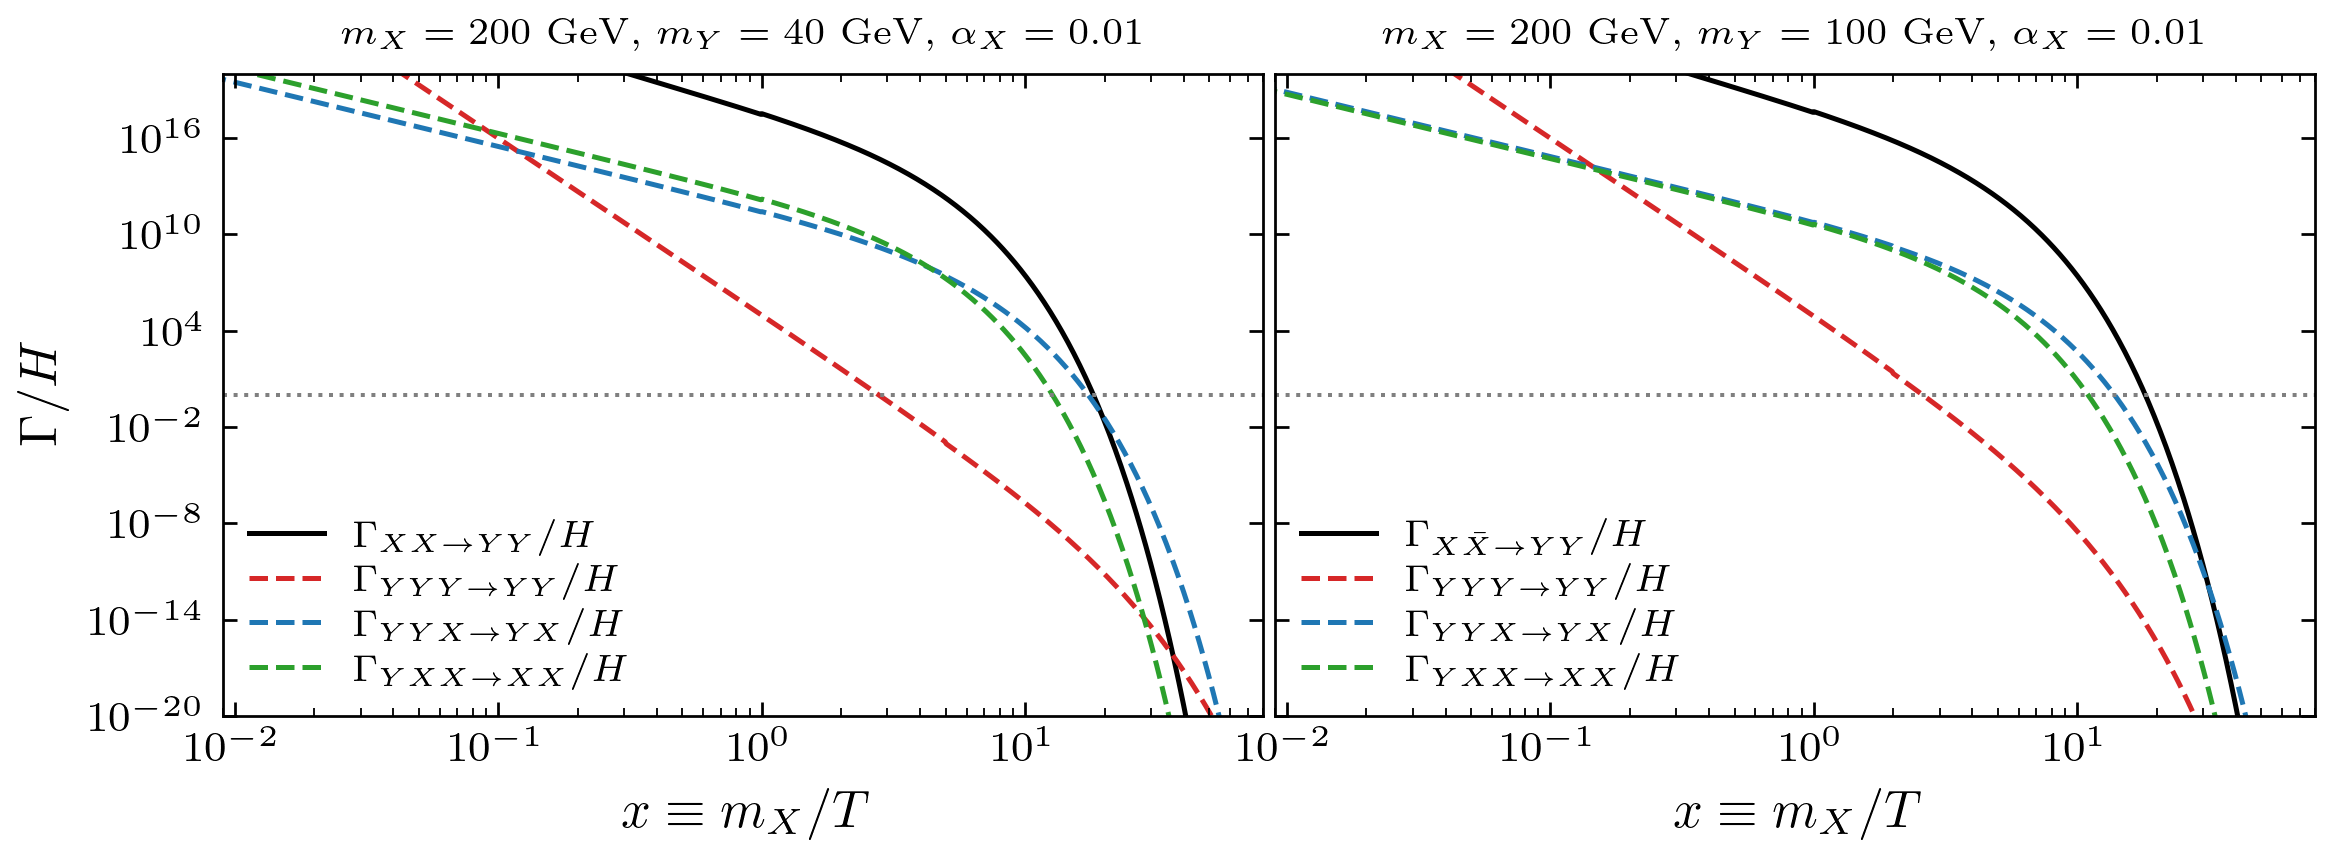

In [46]:
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.50))
gs1 = GridSpec(20,30,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:15])
ax2 = fig1.add_subplot(gs1[:,15:])

ax1.plot(Gs1['x'], Gs1['XX_YY'], label=r'$\Gamma_{X X\to YY}/H$',lw=1,c='k')
ax1.plot(Gs1['x'], Gs1['YYY_YY'], label=r'$\Gamma_{YYY\to YY}/H$', ls='--',lw=1,c='tab:red')
ax1.plot(Gs1['x'], Gs1['YYX_YX'], label=r'$\Gamma_{YYX\to YX}/H$', ls='--',lw=1,c='tab:blue')
ax1.plot(Gs1['x'],Gs1['YXX_XX'], label=r'$\Gamma_{YXX\to XX}/H$', ls='--',lw=1,c='tab:green')
ax1.axhline(1, color='grey', lw=0.8, ls=':')
ax1.set_xlabel(r'$x \equiv m_X / T$')
ax1.set_ylabel(r'$\Gamma / H$')
ax1.set_title(f'$m_X={int(mX1)}$ GeV, $m_Y={int(mX1/r1)}$ GeV, $\\alpha_X={alphaX1}$',fontsize=mpl.rcParams['legend.fontsize'])
ax1.legend()
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_ylim(1e-20, 1e20)
ax1.set_xlim(9e-3,80)

ax2.plot(Gs2['x'], Gs2['XX_YY'], label=r'$\Gamma_{X\bar X\to YY}/H$',lw=1,c='k')
ax2.plot(Gs2['x'], Gs2['YYY_YY'], label=r'$\Gamma_{YYY\to YY}/H$', ls='--',lw=1,c='tab:red')
ax2.plot(Gs2['x'], Gs2['YYX_YX'], label=r'$\Gamma_{YYX\to YX}/H$', ls='--',lw=1,c='tab:blue')
ax2.plot(Gs2['x'],Gs2['YXX_XX'], label=r'$\Gamma_{YXX\to XX}/H$', ls='--',lw=1,c='tab:green')
ax2.axhline(1, color='grey', lw=0.8, ls=':')
ax2.set_xlabel(r'$x \equiv m_X / T$')
ax2.set_title(f'$m_X={int(mX1)}$ GeV, $m_Y={int(mX1/r2)}$ GeV, $\\alpha_X={alphaX1}$',fontsize=mpl.rcParams['legend.fontsize'])
ax2.legend()
ax2.set_yscale("log")
ax2.set_xscale("log")
ax2.set_ylim(1e-20, 1e20)
ax2.set_yticklabels([])
ax2.set_xlim(9e-3,80)
plt.savefig("../figs/rates_vP_check_v0.png", bbox_inches='tight')
plt.savefig("../figs/rates_vP_check_v0.pdf", bbox_inches='tight')
plt.show()
plt.close()

In [47]:
cosmo = Cosmology()
def get_Gammas_hP(mXv,rv,lamv):
    mYv=mXv/rv
    model = HiggsPortal(
            mX=mXv, mY=mYv, gX=2, gY=1, lam=lamv,
            include_antiparticlesX=True, include_antiparticlesY=False)
    Ts = np.logspace(np.log10(1e-2*mXv),np.log10(3e2*mXv),1000)
    xs  = mXv / Ts
    H  = np.array([cosmo.hubble(T) for T in Ts])
    s  = np.array([cosmo.s_entropy(T) for T in Ts])
    sv      = np.array([model.sigmav_XX_to_YY(T) for T in Ts])
    sv2_YYY = np.array([model.sigmav2_YYY_to_YY(T) for T in Ts])
    sv2_YYX = model.sigmav2_YYX_to_YX()
    sv2_YXX = model.sigmav2_YXX_to_XX()
    nXs=np.array([cosmo.species_thermo(m=mXv, T=T, g=2, statistics= "fermion",include_antiparticles = False)["n"] for T in Ts])
    nYs=np.array([cosmo.species_thermo(m=mYv, T=T, g=3, statistics= "boson",include_antiparticles = True)["n"] for T in Ts])
    Gamma_ann = nXs**2 * sv/ (2 * H)
    Gamma_YYY = nYs**2* sv2_YYY / H
    Gamma_YYX = nXs* nYs * sv2_YYX / H
    Gamma_YXX = nXs**2 * sv2_YXX / H
    return {'x':xs,'XX_YY':Gamma_ann, 'YYY_YY':Gamma_YYY, 'YYX_YX':Gamma_YYX, 'YXX_XX':Gamma_YXX}

In [48]:
mX1=200
r1=5
r2=2
lam1=.05
Gs1=get_Gammas_hP(mX1,r1,lam1)
Gs2=get_Gammas_hP(mX1,r2,lam1)

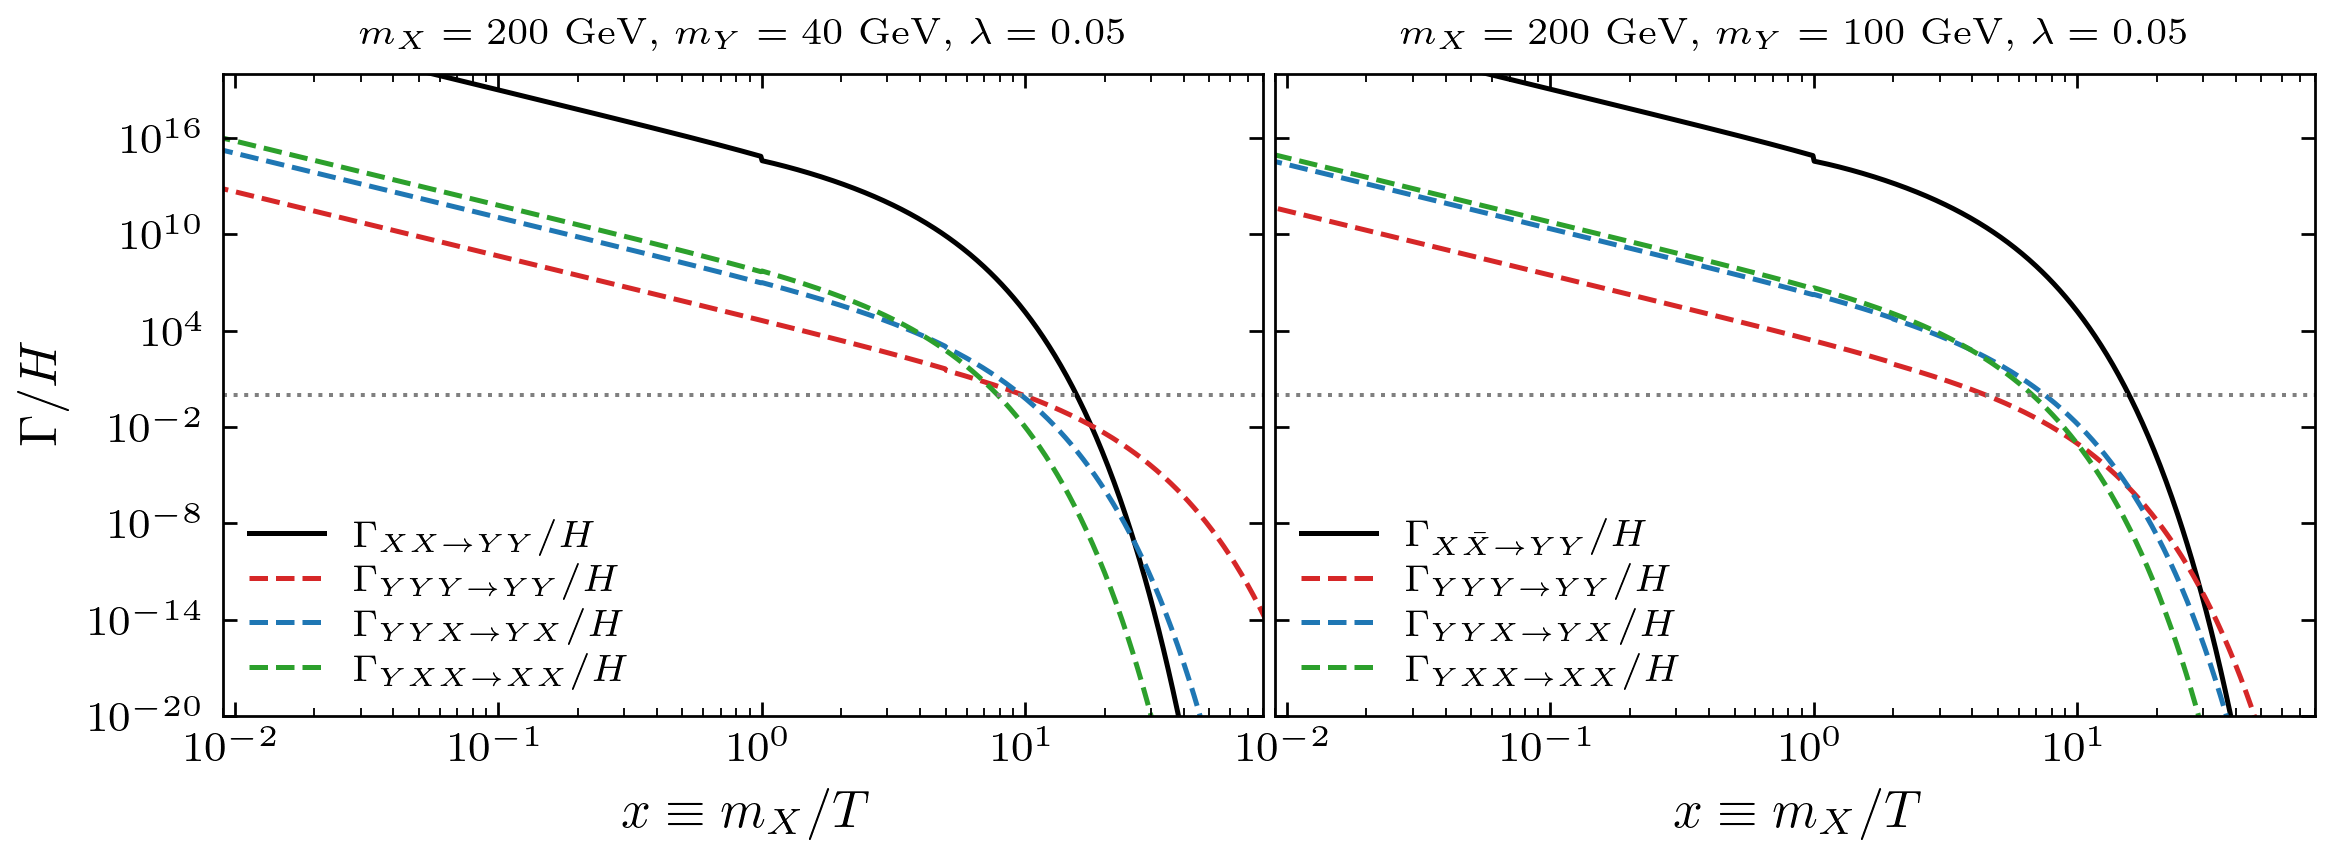

In [49]:
fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.50))
gs1 = GridSpec(20,30,figure=fig1)
ax1 = fig1.add_subplot(gs1[:,:15])
ax2 = fig1.add_subplot(gs1[:,15:])

ax1.plot(Gs1['x'], Gs1['XX_YY'], label=r'$\Gamma_{X X\to YY}/H$',lw=1,c='k')
ax1.plot(Gs1['x'], Gs1['YYY_YY'], label=r'$\Gamma_{YYY\to YY}/H$', ls='--',lw=1,c='tab:red')
ax1.plot(Gs1['x'], Gs1['YYX_YX'], label=r'$\Gamma_{YYX\to YX}/H$', ls='--',lw=1,c='tab:blue')
ax1.plot(Gs1['x'],Gs1['YXX_XX'], label=r'$\Gamma_{YXX\to XX}/H$', ls='--',lw=1,c='tab:green')
ax1.axhline(1, color='grey', lw=0.8, ls=':')
ax1.set_xlabel(r'$x \equiv m_X / T$')
ax1.set_ylabel(r'$\Gamma / H$')
ax1.set_title(f'$m_X={int(mX1)}$ GeV, $m_Y={int(mX1/r1)}$ GeV, $\\lambda={lam1}$',fontsize=mpl.rcParams['legend.fontsize'])
ax1.legend()
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_ylim(1e-20, 1e20)
ax1.set_xlim(9e-3,80)

ax2.plot(Gs2['x'], Gs2['XX_YY'], label=r'$\Gamma_{X\bar X\to YY}/H$',lw=1,c='k')
ax2.plot(Gs2['x'], Gs2['YYY_YY'], label=r'$\Gamma_{YYY\to YY}/H$', ls='--',lw=1,c='tab:red')
ax2.plot(Gs2['x'], Gs2['YYX_YX'], label=r'$\Gamma_{YYX\to YX}/H$', ls='--',lw=1,c='tab:blue')
ax2.plot(Gs2['x'],Gs2['YXX_XX'], label=r'$\Gamma_{YXX\to XX}/H$', ls='--',lw=1,c='tab:green')
ax2.axhline(1, color='grey', lw=0.8, ls=':')
ax2.set_xlabel(r'$x \equiv m_X / T$')
ax2.set_title(f'$m_X={int(mX1)}$ GeV, $m_Y={int(mX1/r2)}$ GeV, $\\lambda={lam1}$',fontsize=mpl.rcParams['legend.fontsize'])
ax2.legend()
ax2.set_yscale("log")
ax2.set_xscale("log")
ax2.set_ylim(1e-20, 1e20)
ax2.set_yticklabels([])
ax2.set_xlim(9e-3,80)
plt.savefig("../figs/rates_hP_check_v0.png", bbox_inches='tight')
plt.savefig("../figs/rates_hP_check_v0.pdf", bbox_inches='tight')
plt.show()
plt.close()